In [9]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 1.1 MB/s eta 0:00:00m eta 0:00:010:00:030m


In [30]:
# train_and_eval.py
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor, Pool

In [31]:

# ---------- تنظیمات ----------
DATA_PATH = "df.csv"   # مسیر فایل CSV که قبلا فرستادی
RANDOM_STATE = 42


In [32]:
# ---------- بارگذاری ----------
df = pd.read_csv(DATA_PATH)
print("Initial shape:", df.shape)


Initial shape: (73268, 79)


In [33]:
# ---------- ستون‌های استفاده‌شده ----------
categorical_cols = ['Country', 'EdLevel', 'Employment']
numerical_cols = ['YearsCodePro']
target_col = 'ConvertedCompYearly'


In [34]:

# ---------- پاک‌سازی اولیه هدف ----------
# تبدیل هدف و عددی کردن
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df[numerical_cols[0]] = pd.to_numeric(df[numerical_cols[0]], errors='coerce')
# حذف ردیف‌هایی که هدف ندارند
df = df.dropna(subset=[target_col]).copy()
print("After dropna target shape:", df.shape)


After dropna target shape: (38071, 79)


In [35]:
# ---------- محدود کردن Outliers هدف ----------
# مقدارهای بسیار بالای حقوق را محدود می‌کنیم (مثال: زیر 300k دلار)
# تو می‌توانی این مقدار را متناسب با داده‌ات تغییر دهی
upper = df[target_col].quantile(0.99)  # 99th percentile
lower = df[target_col].quantile(0.01)  # 1st percentile
print("target quantiles:", lower, upper)
df = df[(df[target_col] >= lower) & (df[target_col] <= upper)].copy()
print("After outlier filtering shape:", df.shape)

target quantiles: 1340.3999999999999 2161310.4000000125
After outlier filtering shape: (37309, 79)


In [36]:
# ---------- تبدیل‌های عددی ناقص ----------
# برای YearsCodePro ممکن است مقادیر like "Less than 1 year" یا "More than 50 years" باشه
# تبدیل تعریف‌شده: "Less than 1 year" -> 0.5 , "More than 50 years" -> 50
def parse_years(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return x
    s = str(x).strip()
    if s.lower().startswith("less"):
        return 0.5
    if s.lower().startswith("more"):
        # اگر عدد در رشته باشه، سعی میکنیم عدد را بگیریم
        m = re.search(r'(\d+)', s)
        if m:
            return float(m.group(1))
        return 50.0
    # معمول تبدیل به عدد
    try:
        return float(s)
    except:
        return np.nan

df['YearsCodePro'] = df['YearsCodePro'].apply(parse_years)

# پر کردن مقادیر گم‌شده عددی با میانه‌ی ستون
for col in numerical_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)

In [37]:

# ---------- مهندسی ویژگی از ستون‌های چندمقداره (اگر وجود دارند) ----------
# بعضی ستون‌ها مثل 'LanguageHaveWorkedWith' ممکن است وجود داشته باشند — به صورت CSV داخل سلول
# ما از بالای پرتکرارترین زبان‌ها فیچر باینری می‌سازیم (presence)
multi_lang_cols = []
for cand in ['LanguageHaveWorkedWith','LanguageWorkedWith','LanguagesWorkedWith']:
    if cand in df.columns:
        multi_lang_cols.append(cand)

# تابع استخراج توکن‌ها از ستون‌های چندمقداره
def extract_top_tokens(df, col, top_n=20):
    # هر سلول را با ; یا , جدا میکند
    s = df[col].dropna().astype(str).str.replace(',', ';')
    tokens = s.str.split(';').explode().str.strip()
    top = tokens.value_counts().head(top_n).index.tolist()
    return top

top_langs = []
for col in multi_lang_cols:
    top = extract_top_tokens(df, col, top_n=20)
    print(f"Top tokens in {col}: {top[:10]}")
    top_langs += top

# منفرد کردن و نگهداری top unique
top_langs = pd.Series(top_langs).unique().tolist()[:30]  # cap 30
print("Final top langs:", top_langs)

# اضافه کردن فیچرهای باینری
for col in multi_lang_cols:
    for lang in top_langs:
        feat = f"lang_{re.sub(r'\\W+','_', lang).lower()}"
        df[feat] = df[col].fillna("").astype(str).str.contains(re.escape(lang)).astype(int)


Top tokens in LanguageHaveWorkedWith: ['JavaScript', 'HTML/CSS', 'SQL', 'Python', 'TypeScript', 'Bash/Shell', 'Java', 'C#', 'PHP', 'C++']
Final top langs: ['JavaScript', 'HTML/CSS', 'SQL', 'Python', 'TypeScript', 'Bash/Shell', 'Java', 'C#', 'PHP', 'C++', 'C', 'PowerShell', 'Go', 'Kotlin', 'Rust', 'Ruby', 'Dart', 'Swift', 'VBA', 'Groovy']


In [38]:
# ---------- انتخاب فیچرها ----------
# از ستون‌های دسته‌ای اصلی استفاده می‌کنیم + فیچرهای زبان + فیچر عددی
lang_feats = [c for c in df.columns if c.startswith("lang_")]
features = categorical_cols + numerical_cols + lang_feats

# اگر ستون categorical‌ای وجود نداشت آن را حذف می‌کنیم
features = [f for f in features if f in df.columns]
print("Using features:", features[:40])

X = df[features].copy()
y = df[target_col].copy()

# تبدیل Nan در categorical به "Unknown"
for c in categorical_cols:
    if c in X.columns:
        X[c] = X[c].fillna("Unknown")

Using features: ['Country', 'EdLevel', 'Employment', 'YearsCodePro', 'lang_javascript', 'lang_html/css', 'lang_sql', 'lang_python', 'lang_typescript', 'lang_bash/shell', 'lang_java', 'lang_c#', 'lang_php', 'lang_c++', 'lang_c', 'lang_powershell', 'lang_go', 'lang_kotlin', 'lang_rust', 'lang_ruby', 'lang_dart', 'lang_swift', 'lang_vba', 'lang_groovy']


In [39]:
# ---------- تقسیم داده ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)


In [40]:
# ---------- آماده‌سازی برای CatBoost ----------
# CatBoost می‌تواند دسته‌ای‌ها را خودش مدیریت کند پس فقط لیست اندیس categorical را می‌دهیم
cat_features = [i for i, col in enumerate(X_train.columns) if col in categorical_cols]

print("Categorical feature names:", [X_train.columns[i] for i in cat_features])


Categorical feature names: ['Country', 'EdLevel', 'Employment']


In [41]:
# ---------- target transform: log1p برای پخش بهتر ----------
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Poolها برای CatBoost
train_pool = Pool(data=X_train, label=y_train_log, cat_features=cat_features)
eval_pool = Pool(data=X_test, label=y_test_log, cat_features=cat_features)

In [42]:
# ---------- تعریف و آموزش مدل ----------
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=100
)

model.fit(train_pool, eval_set=eval_pool, use_best_model=True)

0:	learn: 1.0554033	test: 1.0654565	best: 1.0654565 (0)	total: 10.6ms	remaining: 21.1s
100:	learn: 0.7343011	test: 0.7453005	best: 0.7453005 (100)	total: 922ms	remaining: 17.3s
200:	learn: 0.7183963	test: 0.7411519	best: 0.7411519 (200)	total: 1.81s	remaining: 16.2s
300:	learn: 0.7094492	test: 0.7394563	best: 0.7394563 (300)	total: 2.54s	remaining: 14.3s
400:	learn: 0.7005920	test: 0.7387755	best: 0.7387755 (400)	total: 3.33s	remaining: 13.3s
500:	learn: 0.6931770	test: 0.7382637	best: 0.7381890 (482)	total: 4.08s	remaining: 12.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7381890117
bestIteration = 482

Shrink model to first 483 iterations.


In [43]:

# ---------- پیش‌بینی و بازگرداندن از لاگ ----------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)   # inverse of log1p

In [44]:
# ---------- محاسبات متریک ----------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(f"R2 on original scale: {r2:.4f}")
print(f"MAE on original scale: {mae:.2f}")
print(f"RMSE on original scale: {rmse:.2f}")


R2 on original scale: 0.0689
MAE on original scale: 59406.53
RMSE on original scale: 37130537649.20


In [45]:
# ---------- feature importance ----------
fi = model.get_feature_importance(prettified=True)
print(fi.head(30))

         Feature Id  Importances
0           Country    41.753955
1      YearsCodePro    22.386418
2        Employment     7.623500
3           EdLevel     7.410923
4          lang_php     3.460016
5   lang_typescript     2.377624
6           lang_go     2.089313
7     lang_html/css     1.677116
8           lang_c#     1.389885
9   lang_bash/shell     1.204552
10        lang_ruby     1.112799
11      lang_python     0.945652
12         lang_sql     0.897091
13        lang_rust     0.691509
14        lang_dart     0.687380
15           lang_c     0.582905
16       lang_swift     0.578461
17  lang_powershell     0.555187
18      lang_groovy     0.518260
19      lang_kotlin     0.511678
20         lang_c++     0.509542
21         lang_vba     0.462037
22  lang_javascript     0.308845
23        lang_java     0.265352


In [46]:
# ---------- ذخیره مدل ----------
model.save_model("catboost_salary_model.cbm")
joblib.dump(features, "model_features.pkl")


['model_features.pkl']

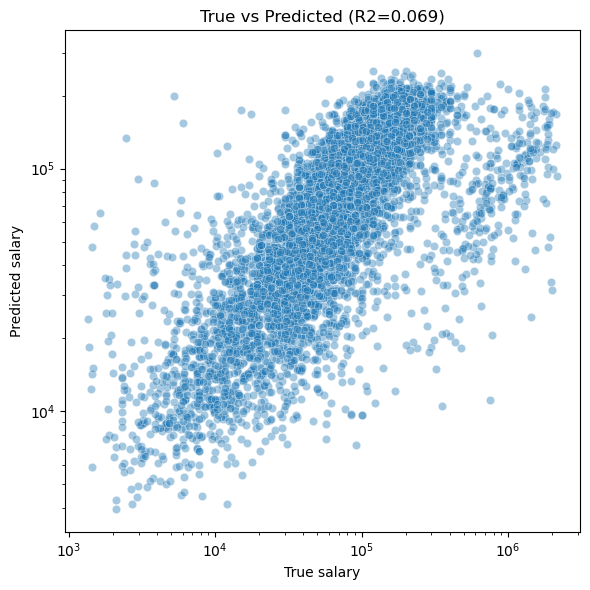

In [47]:
# ---------- ساده‌سازی: نمایش چند نمودار ----------
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("True salary")
plt.ylabel("Predicted salary")
plt.title(f"True vs Predicted (R2={r2:.3f})")
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()